# M01 · 从 Liouville 方程到 Boltzmann 方程

**核心问题**：微观可逆的 Hamilton 力学如何产生宏观不可逆的熵增？

```
Liouville (6N维, 可逆) → BBGKY (精确层级) → 截断 → Boltzmann → H定理 → 流体力学
```

运行：`conda activate m01`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle
import sympy as sp
from sympy import (symbols, Function, exp, ln, sqrt, pi, simplify, Rational,
                   Eq, Integral, oo, Matrix)
from IPython.display import display, Math, Markdown

sp.init_printing(use_latex='mathjax')
plt.rcParams['font.family'] = ['Arial Unicode MS', 'PingFang SC', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 130
plt.rcParams['figure.figsize'] = (12, 5)

---
## 1. BBGKY 理论全景

BBGKY 层级和 Liouville 方程**完全等价**（无近似）。近似只在截断时进入。

| 截断方式 | 得到 |
|----------|------|
| $f_2 = f_1 f_1$（无关联） | **Boltzmann 方程** |
| $f_2 = g(r) f_1 f_1$（平衡关联） | **Enskog 方程**（你的本科论文） |
| 不截断（$s=N$） | Liouville 方程（精确但无用） |

findfont: Failed to find font weight bold, now using 400.


findfont: Failed to find font weight bold, now using 600.


findfont: Failed to find font weight bold, now using 400.


findfont: Failed to find font weight bold, now using 600.


findfont: Failed to find font weight bold, now using 400.


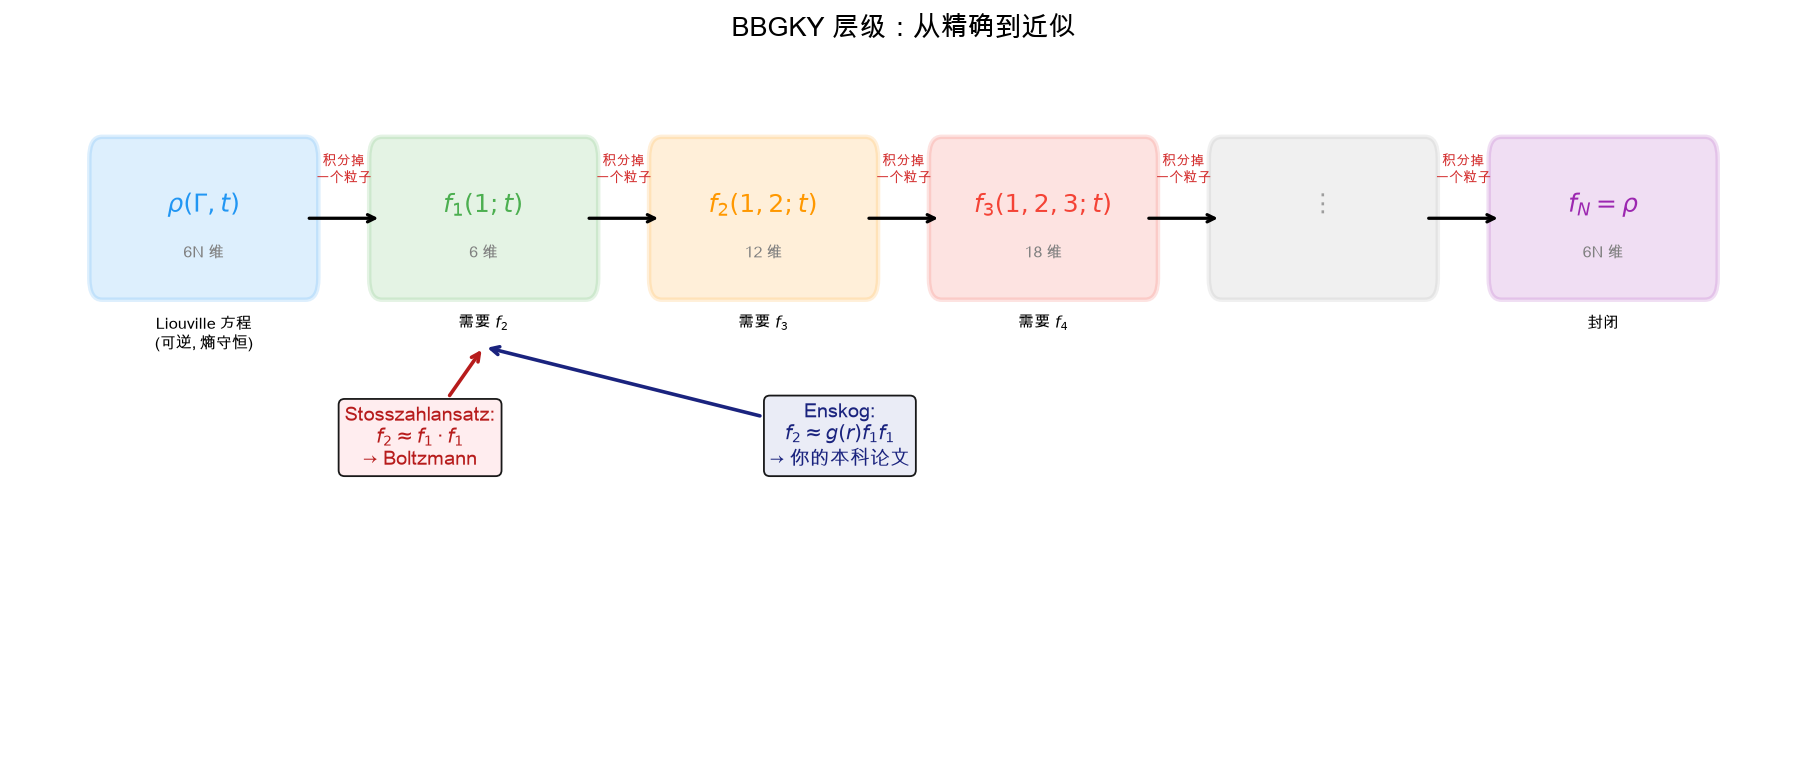

In [2]:
# BBGKY 层级图
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_title('BBGKY 层级：从精确到近似', fontsize=15, fontweight='bold')
levels = [
    (r'$\rho(\Gamma,t)$', '6N 维', 'Liouville 方程\n(可逆, 熵守恒)', '#2196F3'),
    (r'$f_1(1;t)$', '6 维', r'需要 $f_2$', '#4CAF50'),
    (r'$f_2(1,2;t)$', '12 维', r'需要 $f_3$', '#FF9800'),
    (r'$f_3(1,2,3;t)$', '18 维', r'需要 $f_4$', '#F44336'),
    (r'$\vdots$', '', '', '#9E9E9E'),
    (r'$f_N = \rho$', '6N 维', '封闭', '#9C27B0'),
]
xpos = [0, 2.2, 4.4, 6.6, 8.8, 11]
yc = 0.5
for i, (label, dim, note, color) in enumerate(levels):
    x = xpos[i]
    rect = mpatches.FancyBboxPatch((x-0.8, yc-0.28), 1.6, 0.56, boxstyle='round,pad=0.1',
                                    facecolor=color, alpha=0.15, edgecolor=color, lw=2.5)
    ax.add_patch(rect)
    ax.text(x, yc+0.06, label, ha='center', va='center', fontsize=14, color=color, fontweight='bold')
    ax.text(x, yc-0.16, dim, ha='center', va='center', fontsize=9, color='gray')
    if note: ax.text(x, yc-0.45, note, ha='center', va='top', fontsize=9)
    if i < len(levels)-1:
        ax.annotate('', xy=(xpos[i+1]-0.8, yc), xytext=(x+0.8, yc),
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.8))
        ax.text((x+xpos[i+1])/2, yc+0.15, '积分掉\n一个粒子', ha='center', va='bottom', fontsize=8, color='#D32F2F')
ax.annotate('Stosszahlansatz:\n' + r'$f_2 \approx f_1 \cdot f_1$' + '\n→ Boltzmann',
            xy=(xpos[1], yc-0.6), xytext=(xpos[1]-0.5, yc-1.15), fontsize=11, ha='center', color='#B71C1C',
            arrowprops=dict(arrowstyle='->', color='#B71C1C', lw=2),
            bbox=dict(boxstyle='round', facecolor='#FFEBEE', alpha=0.9))
ax.annotate('Enskog:\n' + r'$f_2 \approx g(r) f_1 f_1$' + '\n→ 你的本科论文',
            xy=(xpos[1], yc-0.6), xytext=(xpos[1]+2.8, yc-1.15), fontsize=11, ha='center', color='#1A237E',
            arrowprops=dict(arrowstyle='->', color='#1A237E', lw=2),
            bbox=dict(boxstyle='round', facecolor='#E8EAF6', alpha=0.9))
ax.set_xlim(-1.5, 12.5); ax.set_ylim(-2.0, 1.3); ax.axis('off')
plt.tight_layout(); plt.savefig('fig_bbgky_panorama.png', bbox_inches='tight', dpi=150); plt.show()

---
## 2. Liouville 方程

$$\frac{\partial \rho}{\partial t} + \sum_{i=1}^N \left[\frac{\mathbf{p}_i}{m}\cdot\nabla_i \rho + \mathbf{F}_i\cdot\frac{\partial \rho}{\partial \mathbf{p}_i}\right] = 0$$

相空间流无散 → Gibbs 熵守恒。

In [3]:
# 相空间无散验证 (2粒子, 1D)
q1, q2, p1, p2 = symbols('q_1 q_2 p_1 p_2', real=True)
m = symbols('m', positive=True)
V = Function('V')

H = p1**2/(2*m) + p2**2/(2*m) + V(q1 - q2)

dq1, dq2 = H.diff(p1), H.diff(p2)
dp1, dp2 = -H.diff(q1), -H.diff(q2)

display(Markdown("**Hamilton 量：**"))
display(H)
display(Markdown("**Hamilton 方程：**"))
display(Eq(sp.Symbol(r'\dot{q}_1'), dq1), Eq(sp.Symbol(r'\dot{q}_2'), dq2))
display(Eq(sp.Symbol(r'\dot{p}_1'), dp1), Eq(sp.Symbol(r'\dot{p}_2'), dp2))

div = dq1.diff(q1) + dq2.diff(q2) + dp1.diff(p1) + dp2.diff(p2)
display(Markdown("**相空间散度：**"))
display(Eq(sp.Symbol(r'\nabla_{\Gamma}\cdot\dot{\Gamma}'), div))
display(Markdown(r"散度为零 → 不可压缩 → Gibbs 熵 $S_G = -k_B\int\rho\ln\rho\,d\Gamma$ 守恒。"))

**Hamilton 量：**

               2     2
             p₁    p₂ 
V(q₁ - q₂) + ─── + ───
             2⋅m   2⋅m

**Hamilton 方程：**

           p₁
\dot{q}₁ = ──
           m 

           p₂
\dot{q}₂ = ──
           m 

            ⎛ d        ⎞│          
\dot{p}₁ = -⎜───(V(ξ₁))⎟│          
            ⎝dξ₁       ⎠│ξ₁=q₁ - q₂

           ⎛ d        ⎞│          
\dot{p}₂ = ⎜───(V(ξ₁))⎟│          
           ⎝dξ₁       ⎠│ξ₁=q₁ - q₂

**相空间散度：**

\nabla_{\Gamma}\cdot\dot{\Gamma} = 0

散度为零 → 不可压缩 → Gibbs 熵 $S_G = -k_B\int\rho\ln\rho\,d\Gamma$ 守恒。

---
## 3. BBGKY 第一级

$$\frac{\partial f_1}{\partial t} + \frac{\mathbf{p}_1}{m}\cdot\nabla_1 f_1 = \int \nabla_1 V_{12}\cdot\frac{\partial f_2}{\partial \mathbf{p}_1}\,d^3r_2\,d^3p_2$$

右边需要 $f_2$ → 层级不封闭。

In [4]:
# BBGKY 第一级符号结构
r1, r2, p_1, p_2 = symbols('r_1 r_2 p_1 p_2', real=True)
t = symbols('t', real=True)
f1 = Function('f_1')(r1, p_1, t)
f2 = Function('f_2')(r1, p_1, r2, p_2, t)
V12 = Function('V')(r1 - r2)

lhs = f1.diff(t) + (p_1/m)*f1.diff(r1)
rhs = Integral(V12.diff(r1) * f2.diff(p_1), (r2, -oo, oo), (p_2, -oo, oo))

display(Markdown("**BBGKY 第一级方程 (1D)：**"))
display(Eq(lhs, rhs))
display(Markdown(r"右边含 $f_2$ → 需要下一级方程 → 无穷层级。"))

**BBGKY 第一级方程 (1D)：**

                        ∂                   ∞  ∞                               ↪
                    p₁⋅───(f₁(r₁, p₁, t))   ⌠  ⌠                               ↪
∂                      ∂r₁                  ⎮  ⎮   ∂                         ⎛ ↪
──(f₁(r₁, p₁, t)) + ───────────────────── = ⎮  ⎮  ───(f₂(r₁, p₁, r₂, p₂, t))⋅⎜ ↪
∂t                            m             ⎮  ⎮  ∂p₁                        ⎝ ↪
                                            ⌡  ⌡                               ↪
                                            -∞ -∞                              ↪

↪                                   
↪                                   
↪  d        ⎞│                      
↪ ───(V(ξ₁))⎟│           d(r₂) d(p₂)
↪ dξ₁       ⎠│ξ₁=r₁ - r₂            
↪                                   
↪                                   

右边含 $f_2$ → 需要下一级方程 → 无穷层级。

---
## 4. 硬球极限

$V(r)=\infty$ ($r<d$)，力只在 $r=d$（delta 函数）→ 体积积分变面积分：

$$C[f] = d^2\int d^3v_2\int_{\mathbf{g}\cdot\hat{\sigma}>0} d\Omega\;(\mathbf{g}\cdot\hat{\sigma})[f'f_2' - ff_2]$$

In [5]:
# 碰撞守恒律验证
vx1, vy1, vz1 = symbols('v_{1x} v_{1y} v_{1z}', real=True)
vx2, vy2, vz2 = symbols('v_{2x} v_{2y} v_{2z}', real=True)
sx, sy, sz = symbols('s_x s_y s_z', real=True)

g_dot_s = (vx1-vx2)*sx + (vy1-vy2)*sy + (vz1-vz2)*sz

v1p = Matrix([vx1 - g_dot_s*sx, vy1 - g_dot_s*sy, vz1 - g_dot_s*sz])
v2p = Matrix([vx2 + g_dot_s*sx, vy2 + g_dot_s*sy, vz2 + g_dot_s*sz])
v1 = Matrix([vx1, vy1, vz1])
v2 = Matrix([vx2, vy2, vz2])

display(Markdown(r"""**碰撞后速度** $\mathbf{v}_1' = \mathbf{v}_1 - (\mathbf{g}\cdot\hat{\sigma})\hat{\sigma}$："""))
display(v1p)

display(Markdown("**动量守恒：**"))
mom = simplify(v1p + v2p - v1 - v2)
display(mom)
display(Markdown(r"零向量 → 动量守恒。$\checkmark$"))

display(Markdown(r"**能量守恒**（需 $\hat{\sigma}$ 为单位向量 $s_x^2+s_y^2+s_z^2=1$）："))
KE_diff = v1p.dot(v1p) + v2p.dot(v2p) - v1.dot(v1) - v2.dot(v2)
KE_diff = KE_diff.subs(sx**2 + sy**2 + sz**2, 1)
KE_diff = sp.expand(KE_diff)
# 手动收集: 展开后应含 (sx^2+sy^2+sz^2) 因子
KE_diff2 = sp.collect(sp.expand(KE_diff), [sx**2, sy**2, sz**2, sx*sy, sx*sz, sy*sz])
display(KE_diff2)
display(Markdown(r"代入 $s_x^2+s_y^2+s_z^2=1$ 后为零。$\square$"))

**碰撞后速度** $\mathbf{v}_1' = \mathbf{v}_1 - (\mathbf{g}\cdot\hat{\sigma})\hat{\sigma}$：

⎡-sₓ⋅(sₓ⋅(v_{1x} - v_{2x}) + s_y⋅(v_{1y} - v_{2y}) + s_z⋅(v_{1z} - v_{2z})) +  ↪
⎢                                                                              ↪
⎢-s_y⋅(sₓ⋅(v_{1x} - v_{2x}) + s_y⋅(v_{1y} - v_{2y}) + s_z⋅(v_{1z} - v_{2z})) + ↪
⎢                                                                              ↪
⎣-s_z⋅(sₓ⋅(v_{1x} - v_{2x}) + s_y⋅(v_{1y} - v_{2y}) + s_z⋅(v_{1z} - v_{2z})) + ↪

↪ v_{1x} ⎤
↪        ⎥
↪  v_{1y}⎥
↪        ⎥
↪  v_{1z}⎦

**动量守恒：**

⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣0⎦

零向量 → 动量守恒。$\checkmark$

**能量守恒**（需 $\hat{\sigma}$ 为单位向量 $s_x^2+s_y^2+s_z^2=1$）：

  4 ⎛        2                             2⎞     2 ⎛     2       2        2   ↪
sₓ ⋅⎝2⋅v_{1x}  - 4⋅v_{1x}⋅v_{2x} + 2⋅v_{2x} ⎠ + sₓ ⋅⎝2⋅s_y ⋅v_{1x}  - 4⋅s_y ⋅v ↪

↪                     2       2        2                      2       2        ↪
↪ _{1x}⋅v_{2x} + 2⋅s_y ⋅v_{1y}  - 4⋅s_y ⋅v_{1y}⋅v_{2y} + 2⋅s_y ⋅v_{2x}  + 2⋅s_ ↪

↪  2       2                                                                   ↪
↪ y ⋅v_{2y}  + 4⋅s_y⋅s_z⋅v_{1y}⋅v_{1z} - 4⋅s_y⋅s_z⋅v_{1y}⋅v_{2z} - 4⋅s_y⋅s_z⋅v ↪

↪                                               2       2        2             ↪
↪ _{1z}⋅v_{2y} + 4⋅s_y⋅s_z⋅v_{2y}⋅v_{2z} + 2⋅s_z ⋅v_{1x}  - 4⋅s_z ⋅v_{1x}⋅v_{2 ↪

↪           2       2        2                      2       2        2       2 ↪
↪ x} + 2⋅s_z ⋅v_{1z}  - 4⋅s_z ⋅v_{1z}⋅v_{2z} + 2⋅s_z ⋅v_{2x}  + 2⋅s_z ⋅v_{2z}  ↪

↪            2                             2⎞          ⎛    2                  ↪
↪  - 2⋅v_{1x}  + 4⋅v_{1x}⋅v_{2x} - 2⋅v_{2x} ⎠ + sₓ⋅s_y⋅⎝4⋅sₓ ⋅v_{1x}⋅v_{1y} -  ↪

↪     2               

代入 $s_x^2+s_y^2+s_z^2=1$ 后为零。$\square$

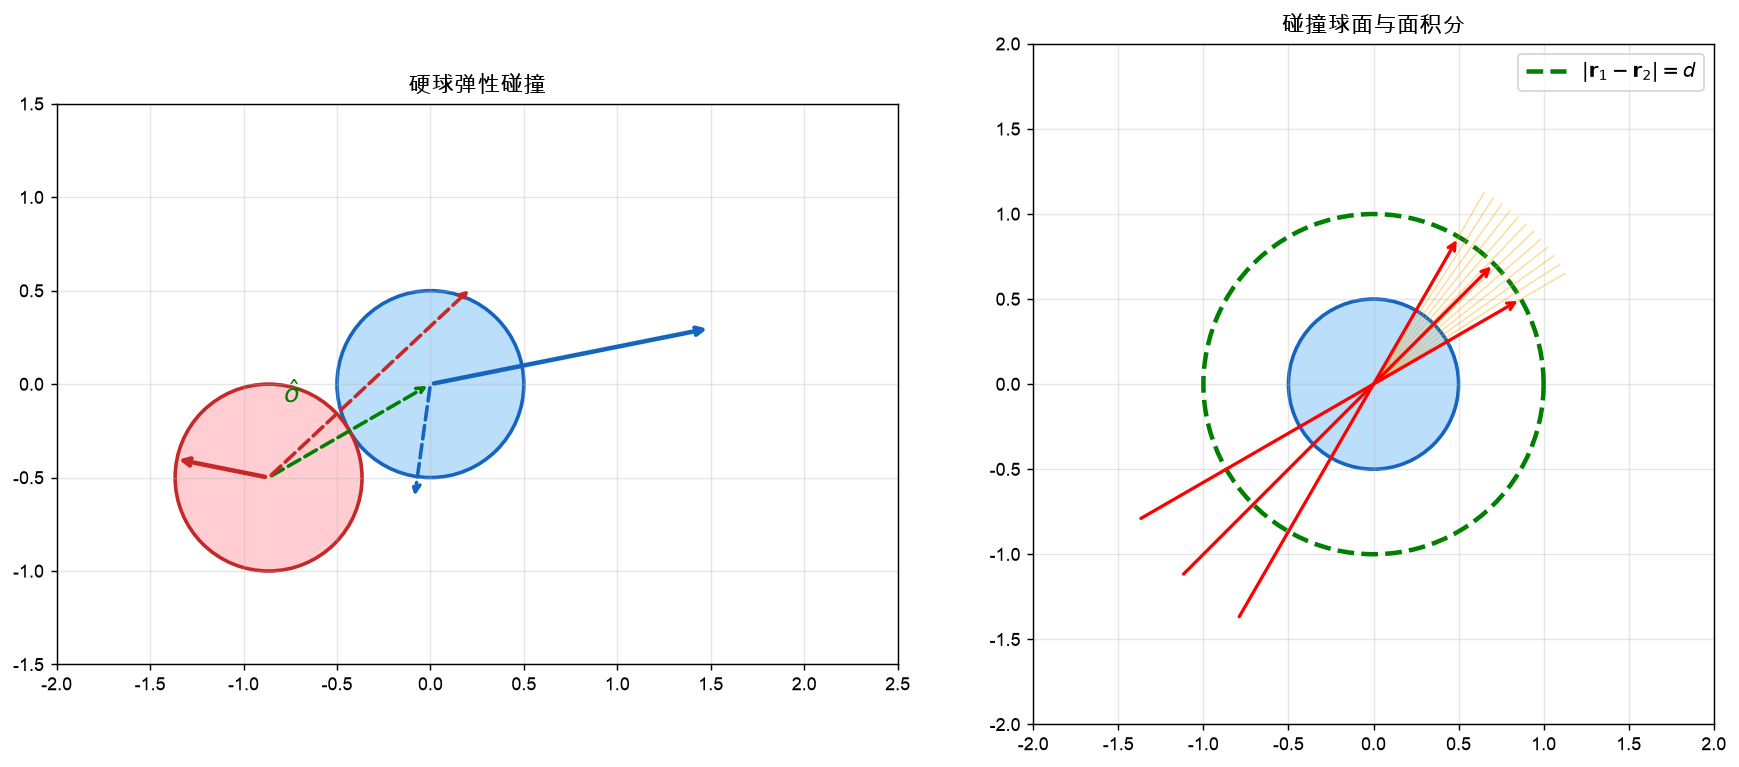

In [6]:
# 碰撞几何可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]; ax.set_title('硬球弹性碰撞', fontsize=13)
d = 1.0
r1_pos = np.array([0.0, 0.0]); r2_pos = np.array([-d*np.cos(np.pi/6), -d*np.sin(np.pi/6)])
sigma_hat = (r1_pos - r2_pos) / np.linalg.norm(r1_pos - r2_pos)
v1_arr = np.array([1.5, 0.3]); v2_arr = np.array([-0.5, 0.1])
g_arr = v1_arr - v2_arr
v1p_arr = v1_arr - np.dot(g_arr, sigma_hat)*sigma_hat
v2p_arr = v2_arr + np.dot(g_arr, sigma_hat)*sigma_hat
ax.add_patch(Circle(r1_pos, d/2, facecolor='#BBDEFB', edgecolor='#1565C0', lw=2))
ax.add_patch(Circle(r2_pos, d/2, facecolor='#FFCDD2', edgecolor='#C62828', lw=2))
ax.annotate('', xy=r1_pos, xytext=r2_pos, arrowprops=dict(arrowstyle='->', color='green', lw=2, ls='--'))
mid = (r1_pos+r2_pos)/2
ax.text(mid[0]-0.35, mid[1]+0.15, r'$\hat{\sigma}$', color='green', fontsize=14)
for v, r, c in [(v1_arr,r1_pos,'#1565C0'),(v2_arr,r2_pos,'#C62828')]:
    ax.annotate('', xy=r+v, xytext=r, arrowprops=dict(arrowstyle='->', color=c, lw=2.5))
for v, r, c in [(v1p_arr,r1_pos,'#1565C0'),(v2p_arr,r2_pos,'#C62828')]:
    ax.annotate('', xy=r+v, xytext=r, arrowprops=dict(arrowstyle='->', color=c, lw=2, ls='dashed'))
ax.set_xlim(-2, 2.5); ax.set_ylim(-1.5, 1.5); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

ax = axes[1]; ax.set_title('碰撞球面与面积分', fontsize=13)
ax.add_patch(Circle([0,0], d/2, facecolor='#BBDEFB', edgecolor='#1565C0', lw=2))
theta = np.linspace(0, 2*np.pi, 100)
ax.plot(d*np.cos(theta), d*np.sin(theta), 'g--', lw=2.5, label=r'$|\mathbf{r}_1-\mathbf{r}_2|=d$')
for t_ang in np.linspace(np.pi/6, np.pi/3, 12):
    ax.plot([0, 1.3*d*np.cos(t_ang)], [0, 1.3*d*np.sin(t_ang)], 'orange', alpha=0.4, lw=0.8)
for angle in [np.pi/6, np.pi/4, np.pi/3]:
    s = np.array([1.6*d*np.cos(angle+np.pi), 1.6*d*np.sin(angle+np.pi)])
    e = np.array([d*np.cos(angle), d*np.sin(angle)])
    ax.annotate('', xy=e, xytext=s, arrowprops=dict(arrowstyle='->', color='red', lw=1.8))
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2); ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('fig_collision_geometry.png', bbox_inches='tight', dpi=150); plt.show()

---
## 5. Stosszahlansatz → Boltzmann 方程

**Stosszahlansatz**（碰撞数假设）：碰撞前两粒子统计无关：$f_2 \approx f_1 \cdot f_1$

代入 BBGKY → Boltzmann 方程。**不可逆性在此进入**。

---
## 6. H 定理

$$H = \int f\ln f\,d^3v, \qquad \frac{dH}{dt} \leq 0$$

核心：$(\ln x - \ln y)(x-y) \geq 0$

In [7]:
# H 定理验证
f1, f2, f1p, f2p = symbols("f_1 f_2 f_1' f_2'", positive=True)
x_expr = f1p * f2p
y_expr = f1 * f2
integrand = (ln(x_expr) - ln(y_expr)) * (x_expr - y_expr)

display(Markdown("**H 定理被积函数：**"))
display(integrand)

display(Markdown(r"**等号条件**（细致平衡 $f_1'f_2' = f_1 f_2$）："))
display(Eq(integrand.subs([(f1p, f1), (f2p, f2)]), 0))

display(Markdown(r"**数值验证** $(\ln a - \ln b)(a-b) \geq 0$："))
np.random.seed(42)
for _ in range(5):
    a, b = np.random.exponential(1.5)+0.01, np.random.exponential(1.5)+0.01
    val = (np.log(a)-np.log(b))*(a-b)
    display(Math(r"(\ln %.3f - \ln %.3f)(%.3f - %.3f) = %.4f \geq 0" % (a, b, a, b, val)))

**H 定理被积函数：**

(-f₁⋅f₂ + f_1'⋅f_2')⋅(-log(f₁⋅f₂) + log(f_1'⋅f_2'))

**等号条件**（细致平衡 $f_1'f_2' = f_1 f_2$）：

True

**数值验证** $(\ln a - \ln b)(a-b) \geq 0$：

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

---
## 7. 细致平衡 → Maxwell 分布

In [8]:
# Maxwell 分布
m_s, T, n_s, kB = symbols('m T n k_B', positive=True)
v_sq = symbols('v^2', positive=True)
f_MB = n_s * (m_s/(2*pi*kB*T))**Rational(3,2) * exp(-m_s*v_sq/(2*kB*T))
display(Markdown("**Maxwell-Boltzmann 分布：**"))
display(f_MB)
display(Markdown(r"弹性碰撞守恒 $|\mathbf{v}_1|^2+|\mathbf{v}_2|^2 = |\mathbf{v}_1'|^2+|\mathbf{v}_2'|^2$ → $f_1 f_2 = f_1' f_2'$。$\square$"))

**Maxwell-Boltzmann 分布：**

           -m⋅v²  
           ───────
    3/2    2⋅T⋅k_B
√2⋅m   ⋅n⋅ℯ       
──────────────────
   3/2  3/2    3/2
4⋅π   ⋅T   ⋅k_B   

弹性碰撞守恒 $|\mathbf{v}_1|^2+|\mathbf{v}_2|^2 = |\mathbf{v}_1'|^2+|\mathbf{v}_2'|^2$ → $f_1 f_2 = f_1' f_2'$。$\square$

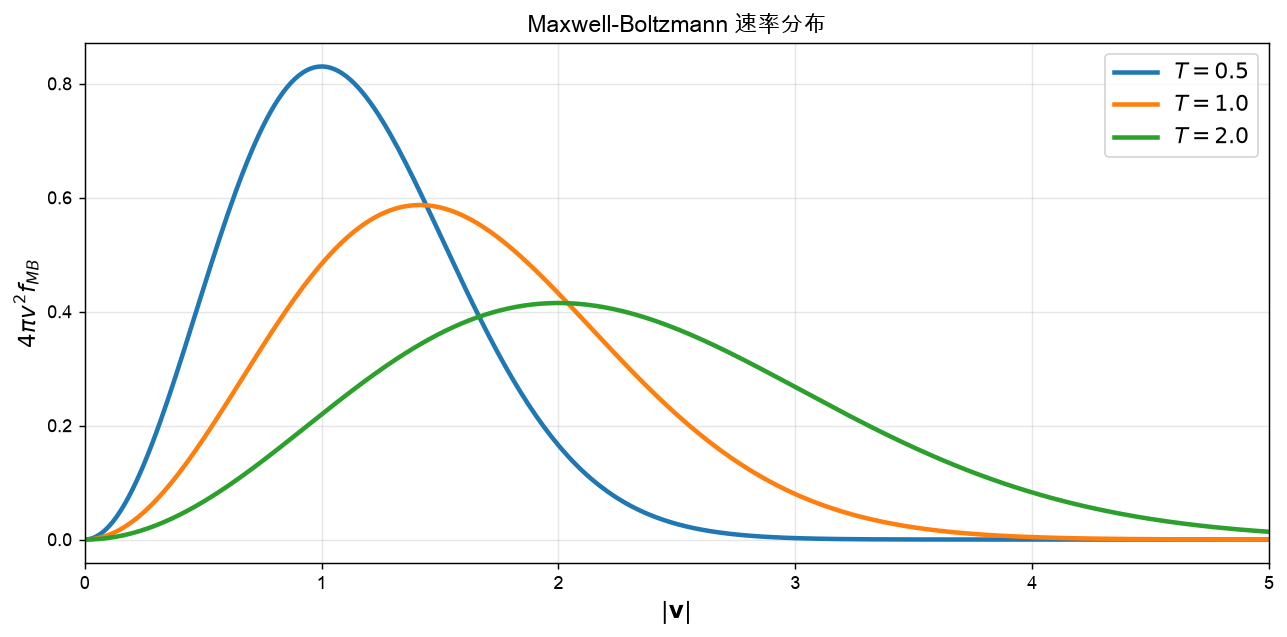

In [9]:
# Maxwell 速率分布图
fig, ax = plt.subplots(figsize=(10, 5))
v = np.linspace(0, 5, 300)
for T_val in [0.5, 1.0, 2.0]:
    f_mb = 4*np.pi*(1/(2*np.pi*T_val))**1.5 * v**2 * np.exp(-v**2/(2*T_val))
    ax.plot(v, f_mb, lw=2.5, label=f'$T = {T_val}$')
ax.set_xlabel(r'$|\mathbf{v}|$', fontsize=13); ax.set_ylabel(r'$4\pi v^2 f_{MB}$', fontsize=13)
ax.set_title('Maxwell-Boltzmann 速率分布', fontsize=13)
ax.legend(fontsize=12); ax.grid(True, alpha=0.3); ax.set_xlim(0, 5)
plt.tight_layout(); plt.savefig('fig_maxwell.png', bbox_inches='tight', dpi=150); plt.show()

---
## 8. 相空间细丝化

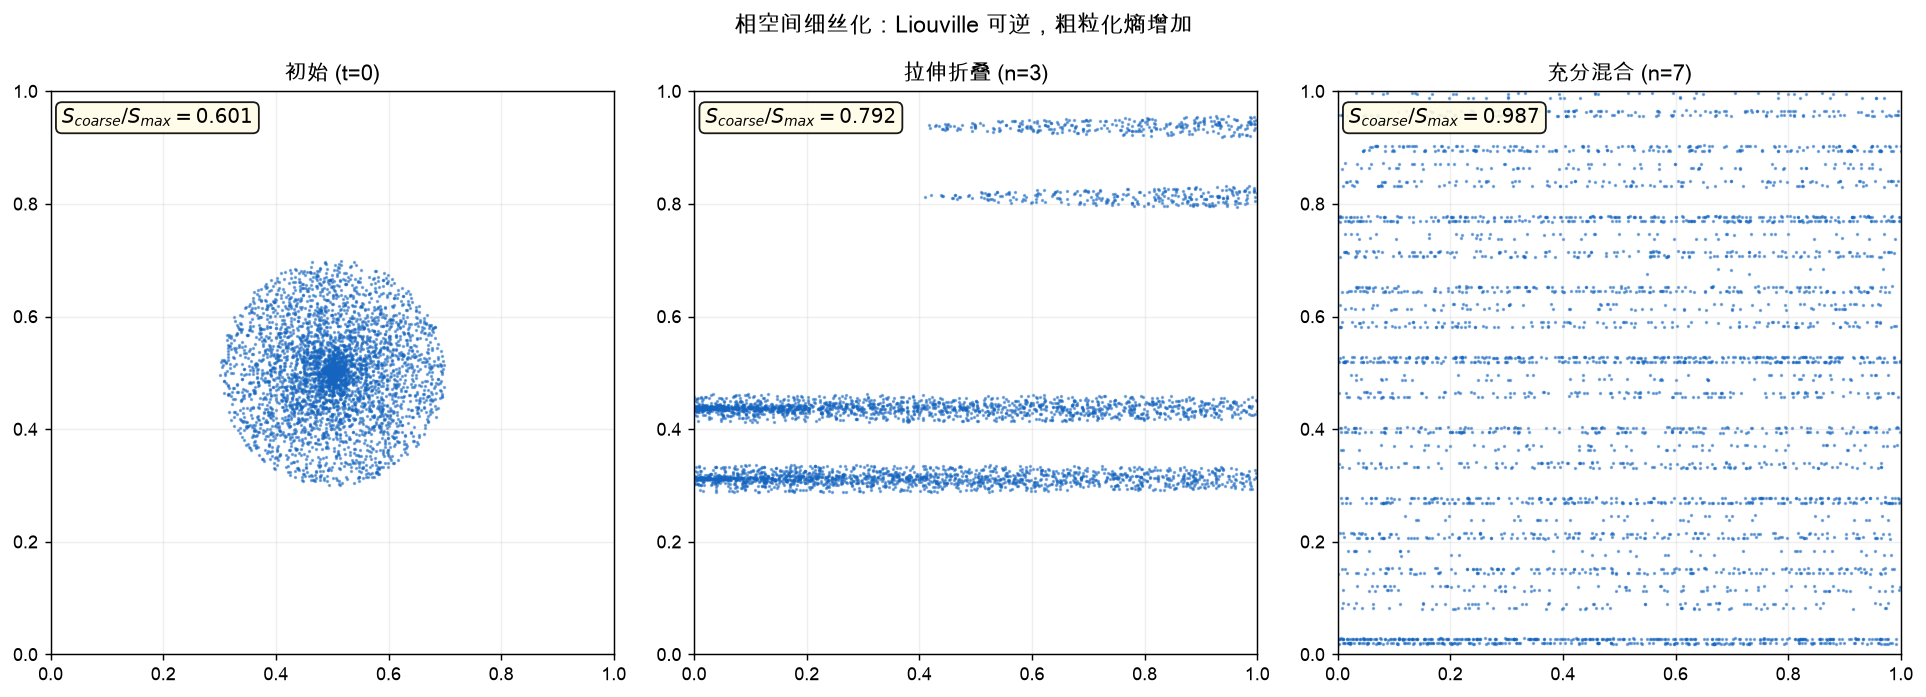

In [10]:
# Baker's map
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
np.random.seed(42)
N_pts = 4000
th0 = np.random.uniform(0, 2*np.pi, N_pts)
r0 = np.random.uniform(0, 0.25, N_pts)
x0 = (r0*np.cos(th0)+0.25)/0.5*0.4+0.3
y0 = (r0*np.sin(th0)+0.25)/0.5*0.4+0.3

def baker(x, y, n):
    for _ in range(n):
        xn, yn = 2*x, y/2
        mask = xn > 1
        xn[mask] = 2-xn[mask]; yn[mask] += 0.5
        x, y = xn, yn
    return x, y

for idx, (n_it, title) in enumerate(zip([0,3,7], ['初始 (t=0)', '拉伸折叠 (n=3)', '充分混合 (n=7)'])):
    ax = axes[idx]
    xt, yt = (x0.copy(), y0.copy()) if n_it==0 else baker(x0.copy(), y0.copy(), n_it)
    ax.scatter(xt, yt, s=0.8, alpha=0.5, c='#1565C0')
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_title(title, fontsize=12)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)
    nb = 16
    H, _, _ = np.histogram2d(xt, yt, bins=nb, range=[[0,1],[0,1]])
    Hn = H/H.sum(); Hn = Hn[Hn>0]
    S = -np.sum(Hn*np.log(Hn)); Smax = np.log(nb**2)
    ax.text(0.02, 0.97, f'$S_{{coarse}}/S_{{max}} = {S/Smax:.3f}$', transform=ax.transAxes, fontsize=11, va='top',
            bbox=dict(boxstyle='round', facecolor='#FFFDE7', alpha=0.9))
plt.suptitle('相空间细丝化：Liouville 可逆，粗粒化熵增加', fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig('fig_filamentation.png', bbox_inches='tight', dpi=150); plt.show()

---
## 9. Chapman-Enskog 展开

| 阶 | 得到 | 物理 |
|---|---|---|
| 零阶 | Euler | 无耗散 |
| 一阶 | Navier-Stokes | $\eta = \frac{5}{16d^2}\sqrt{\frac{mk_BT}{\pi}}$（与密度无关） |

**涌现判据**：$\text{Kn}\ll 1$。

---
## 10. Boltzmann vs Enskog

| | Boltzmann | Enskog（你的本科论文） |
|---|---|---|
| $f_2$ | $f_1(\mathbf{r})f_1(\mathbf{r})$ | $g(r)f_1(\mathbf{r})f_1(\mathbf{r}\pm d\hat{\sigma})$ |

---
## 练习

1. 手推 BBGKY 第一级
2. Stosszahlansatz → Boltzmann 方程
3. 证明 H 定理
4. Chapman-Enskog → $\eta$
5. DSMC 模拟验证 Maxwell 分布